<a href="https://colab.research.google.com/github/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/Causal_Inference_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# Load the dataset from the provided path
online_retail = ('/content/drive/MyDrive/data/online_retail_uci.xlsx')
data = pd.read_excel(online_retail)

In [8]:
import io
import sys
import numpy as np
import pandas as pd
from IPython.display import display

print("Python:", sys.version.split()[0], "NumPy:", np.__version__, "pandas:", pd.__version__)
filename = "insurance_2025.csv"
raw = pd.read_csv(filename)

Python: 3.13.15 NumPy: 2.1.3 pandas: 2.2.3


In [9]:
required = ["age", "sex", "bmi", "children", "smoker", "region", "charges", "insuranceclaim"]
assert set(required).issubset(raw.columns), "Unexpected CSV schema"
data = raw[required].apply(pd.to_numeric, errors="raise").copy()
assert np.isfinite(data.to_numpy()).all(), "Resolve missing/nonfinite values explicitly before fitting"
assert set(data.smoker.unique()) == {0, 1}, "Expected smoker codes 0 and 1"
assert set(data.sex.unique()).issubset({0, 1}), "Unexpected sex codes"
assert set(data.region.unique()).issubset({0, 1, 2, 3}), "Unexpected region codes"
assert data.age.between(18, 120).all() and (data.charges >= 0).all()
print("Shape:", data.shape, "Exact duplicate rows:", data.duplicated().sum())
# Preserve all records: identical rows do not prove duplicate people without an ID.
# A later sensitivity check removes identical rows and shows the difference.
display(data.groupby("smoker").charges.agg(["count", "mean", "median", "std"]))
print("No currency, date, or category meanings are inferred beyond the stated working assumptions.")

Shape: (1338, 8) Exact duplicate rows: 1


,count,mean,median,std
smoker,,,,
0,1064,8434.268298,7345.40530,5993.781819
1,274,32050.231832,34456.34845,11541.547176


No currency, date, or category meanings are inferred beyond the stated working assumptions.


In [10]:
def features(d, extended=False):
    # Fixed scales avoid fitting preprocessing on held-out data.
    age = (d.age.to_numpy(float) - 40) / 15
    f = {"intercept": np.ones(len(d)), "age": age, "age_squared": age**2,
         "sex_code_1": d.sex.to_numpy(float)}
    for value in (1, 2, 3):
        f[f"region_{value}"] = (d.region.to_numpy() == value).astype(float)
    if extended:
        bmi = (d.bmi.to_numpy(float) - 30) / 6
        f.update(bmi=bmi, bmi_squared=bmi**2,
                 children=d.children.to_numpy(float), age_bmi=age*bmi)
    return pd.DataFrame(f)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -35, 35)))

def fit_logistic(x, t):
    b = np.zeros(x.shape[1])
    penalty = np.eye(x.shape[1]) * 1e-6
    penalty[0, 0] = 0
    for _ in range(100):
        p = sigmoid(x @ b)
        h = x.T @ (np.maximum(p * (1-p), 1e-10)[:, None] * x) + penalty
        step = np.linalg.solve(h, x.T @ (t-p) - penalty @ b)
        b += step
        if np.max(np.abs(step)) < 1e-8:
            return b
    raise RuntimeError("Propensity model failed to converge; inspect covariates and separation")

def estimate(d, extended=False, seed=42, clip=0.01):
    d = d.reset_index(drop=True)
    x = features(d, extended).to_numpy(float)
    t, y = d.smoker.to_numpy(int), d.charges.to_numpy(float)
    assert min(np.bincount(t, minlength=2)) >= 25, "Too few rows per group"
    rng = np.random.default_rng(seed)
    fold = np.zeros(len(d), dtype=int)
    for group in (0, 1):
        indices = rng.permutation(np.flatnonzero(t == group))
        fold[indices] = np.arange(len(indices)) % 5
    e_raw, m0, m1 = (np.zeros(len(d)) for _ in range(3))
    for k in range(5):
        train, test = fold != k, fold == k
        e_raw[test] = sigmoid(x[test] @ fit_logistic(x[train], t[train]))
        for group, dest in [(0, m0), (1, m1)]:
            mask = train & (t == group)
            coef = np.linalg.lstsq(x[mask], y[mask], rcond=None)[0]
            dest[test] = x[test] @ coef
    e = np.clip(e_raw, clip, 1-clip)
    score = m1-m0 + t*(y-m1)/e - (1-t)*(y-m0)/(1-e)
    ate = score.mean()
    se = score.std(ddof=1) / np.sqrt(len(d))
    w1, w0 = t/e, (1-t)/(1-e)
    summary = {"n": len(d), "raw_gap": y[t==1].mean()-y[t==0].mean(),
               "outcome_regression": (m1-m0).mean(),
               "IPW_normalized": np.sum(w1*y)/w1.sum()-np.sum(w0*y)/w0.sum(),
               "AIPW": ate, "approx_95_low": ate-1.96*se,
               "approx_95_high": ate+1.96*se,
               "clipped_fraction": np.mean(e != e_raw)}
    assert np.isfinite(list(summary.values())).all()
    return {"summary": summary, "propensity": e_raw, "weights": w1+w0,
            "scores": score, "data": d, "extended": extended}

primary = estimate(data)
display(pd.Series(primary["summary"], name="Primary specification").to_frame().round(3))

,Primary specification
n,1338.000
raw_gap,23615.964
outcome_regression,23571.405
IPW_normalized,23556.860
AIPW,23634.615
approx_95_low,22235.200
approx_95_high,25034.029
clipped_fraction,0.000


In [11]:
def diagnostics(result):
    d, e, w = result["data"], result["propensity"], result["weights"]
    t = d.smoker.to_numpy(int)
    display(pd.DataFrame({"smoker": t, "propensity": e}).groupby("smoker").propensity.describe())
    for group in (0, 1):
        wg = w[t==group]
        print(f"Group {group}: n={len(wg)}, effective n={wg.sum()**2/(wg@wg):.1f}, max weight={wg.max():.2f}")
    print("Fraction outside [0.05, 0.95]:", np.mean((e < .05) | (e > .95)))
    rows = []
    for name, values in features(d, result["extended"]).drop(columns="intercept").items():
        a = values.to_numpy()
        sd = np.sqrt((a[t==1].var(ddof=1)+a[t==0].var(ddof=1))/2)
        before = (a[t==1].mean()-a[t==0].mean()) / sd if sd else np.nan
        after = (np.average(a[t==1], weights=w[t==1])-np.average(a[t==0], weights=w[t==0])) / sd if sd else np.nan
        rows.append({"feature": name, "SMD_before": before, "SMD_after": after})
    balance = pd.DataFrame(rows)
    display(balance.round(3))
    if (balance.SMD_after.abs() > .1).any():
        print("Residual measured imbalance: inspect model specification before interpretation.")
    return balance

balance = diagnostics(primary)

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
0,1064.0,0.203721,0.046354,0.103458,0.166021,0.203271,0.233110,0.320147
1,274.0,0.210450,0.049651,0.103458,0.172343,0.207738,0.240773,0.320147


Group 0: n=1064, effective n=1060.2, max weight=1.47
Group 1: n=274, effective n=257.8, max weight=9.67
Fraction outside [0.05, 0.95]: 0.0


,feature,SMD_before,SMD_after
0,age,-0.062,-0.004
1,age_squared,-0.018,0.022
2,sex_code_1,0.190,-0.008
3,region_1,-0.093,0.015
4,region_2,0.166,-0.017
5,region_3,-0.093,0.007


In [12]:
checks = {"primary": primary}
checks["add_BMI_children_timing_uncertain"] = estimate(data, extended=True)
checks["seed_7"] = estimate(data, seed=7)
checks["seed_101"] = estimate(data, seed=101)
checks["clip_0.005"] = estimate(data, clip=.005)
checks["clip_0.05"] = estimate(data, clip=.05)
checks["drop_exact_duplicates"] = estimate(data.drop_duplicates())
comparison = pd.DataFrame({name: r["summary"] for name, r in checks.items()}).T
display(comparison.round(2))
print("Alternative specification diagnostics:")
alternative_balance = diagnostics(checks["add_BMI_children_timing_uncertain"])

,n,raw_gap,outcome_regression,IPW_normalized,AIPW,approx_95_low,approx_95_high,clipped_fraction
primary,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
add_BMI_children_timing_uncertain,1338.0,23615.96,23989.96,24098.61,23919.37,22986.06,24852.68,0.0
seed_7,1338.0,23615.96,23576.40,23456.64,23313.53,21949.48,24677.59,0.0
seed_101,1338.0,23615.96,23577.61,23558.42,23544.11,22194.07,24894.16,0.0
clip_0.005,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
clip_0.05,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
drop_exact_duplicates,1337.0,23609.57,23559.29,23540.54,23617.86,22220.49,25015.22,0.0


Alternative specification diagnostics:


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
0,1064.0,0.204661,0.051356,0.074392,0.164350,0.201062,0.234922,0.594550
1,274.0,0.206995,0.052796,0.081258,0.167237,0.203289,0.240243,0.407649


Group 0: n=1064, effective n=1058.6, max weight=2.47
Group 1: n=274, effective n=255.0, max weight=12.31
Fraction outside [0.05, 0.95]: 0.0


,feature,SMD_before,SMD_after
0,age,-0.062,-0.002
1,age_squared,-0.018,0.022
2,sex_code_1,0.190,-0.006
3,region_1,-0.093,0.012
4,region_2,0.166,-0.008
5,region_3,-0.093,0.010
6,bmi,0.009,0.021
7,bmi_squared,0.061,0.043
8,children,0.019,-0.013
9,age_bmi,-0.067,0.010


In [13]:
s = primary["summary"]
print(f"Adjusted smoking–charges contrast: {s['AIPW']:,.1f} charge units")
print(f"Approximate 95% interval: [{s['approx_95_low']:,.1f}, {s['approx_95_high']:,.1f}]")
print("Causal interpretation remains conditional on the unverified assumptions above.")
comparison.to_csv("causal_sensitivity_results.csv", index_label="specification")
balance.to_csv("covariate_balance.csv", index=False)
# Optional downloads after reviewing results:
# files.download("causal_sensitivity_results.csv")
# files.download("covariate_balance.csv")

Adjusted smoking–charges contrast: 23,634.6 charge units
Approximate 95% interval: [22,235.2, 25,034.0]
Causal interpretation remains conditional on the unverified assumptions above.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 13})
BLUE, ORANGE, GRAY = "#2166ac", "#c65d19", "#687684"
GROUPS = ["Non-smoker (0)", "Smoker (1)"]
def charge_axis(ax, axis="x"):
    getattr(ax, axis + "axis").set_major_formatter(StrMethodFormatter("{x:,.0f}"))

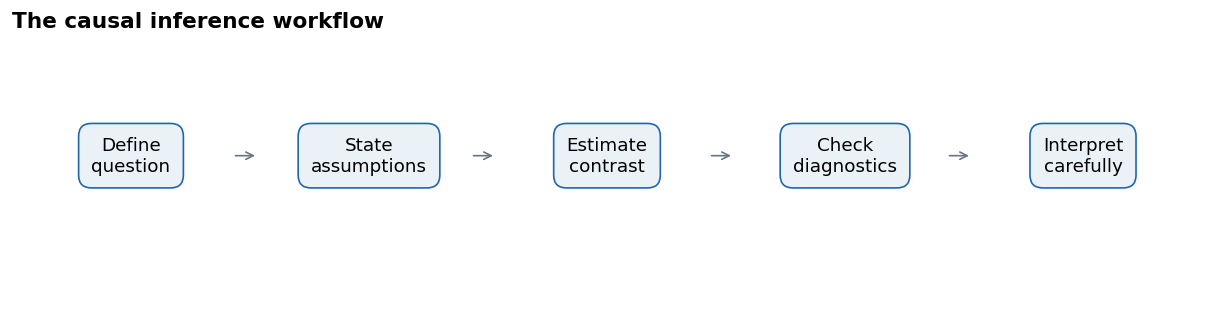

In [19]:
fig, ax = plt.subplots(figsize=(10, 2.6), layout="constrained")
ax.axis("off")
stages = ["Define question", "State assumptions", "Estimate contrast", "Check diagnostics", "Interpret carefully"]
for i, label in enumerate(stages):
    x = .015 + i*.2
    ax.text(x+.085, .57, label.replace(" ", "\n", 1), ha="center", va="center",
            bbox=dict(boxstyle="round,pad=.7", facecolor="#eaf2f8", edgecolor=BLUE), transform=ax.transAxes)
    if i < 4:
        ax.annotate("", xy=(x+.192, .57), xytext=(x+.17, .57), xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_title("The causal inference workflow", loc="left")
plt.show()

Follow the sections from left to right. Statistical estimation comes after specifying the causal question and assumptions.

# 1. Design before estimation

Let T be smoking status and Y recorded charges. The proposed estimand is the average treatment effect, E[Y(1) − Y(0)], for a population represented by these records, under a specified smoking intervention. The file alone cannot define that intervention or population precisely.

The working graph assumes age, sex and region (X) precede exposure and affect both T and Y:

X → T → Y

X ────→ Y

U → T and U → Y  (possible unmeasured common causes)

Identification by adjustment requires conditional exchangeability (no remaining U after adjustment), overlap (both exposures possible at every X), consistency (well-defined exposure), no interference, and suitable sampling. Income, prior illness and smoking history are absent, so exchangeability is unverified. If U remains, the graph does not identify the causal effect.

Primary adjustment: age, sex, region. Region must reflect residence before the exposure. BMI and children have uncertain temporal roles and are included only in an alternative specification. If BMI is affected by smoking, controlling it can remove part of the total effect or introduce bias. The alternative is not automatically a better causal estimate. Do not adjust for insuranceclaim: its construction and temporal role are unknown.

We compare the raw mean gap, outcome regression, inverse-probability weighting (IPW), and augmented IPW (AIPW). AIPW combines exposure and outcome models. Double robustness concerns model specification under identification assumptions; it does not fix unmeasured confounding.

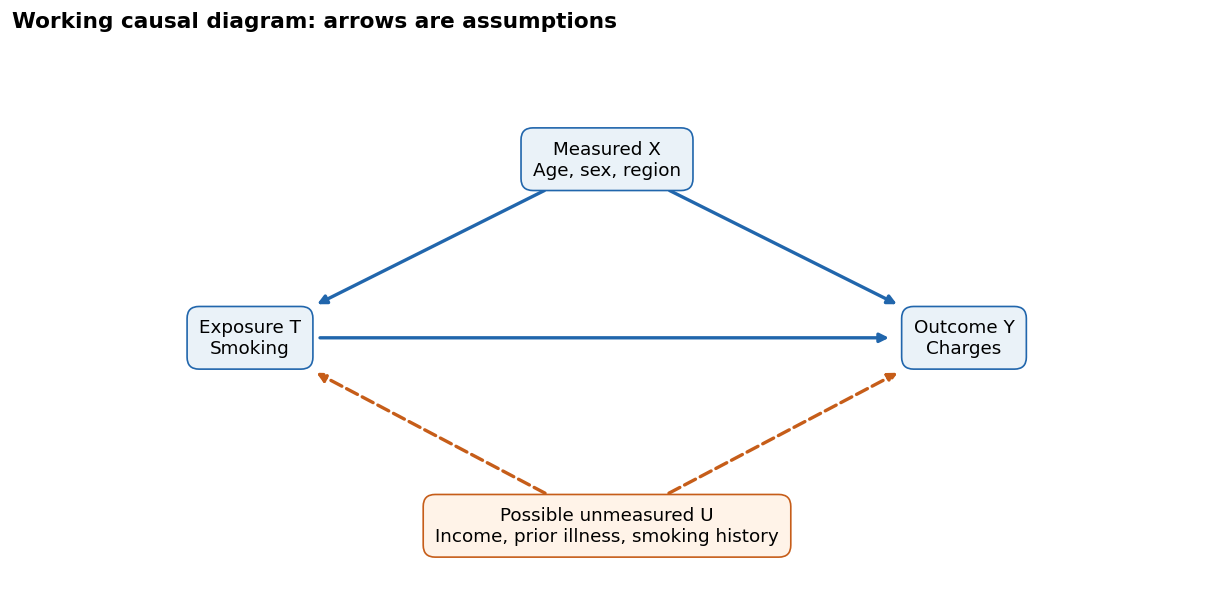

In [20]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.set(xlim=(0, 10), ylim=(0, 6)); ax.axis("off")
positions = {"X": (5, 4.7), "T": (2, 2.8), "Y": (8, 2.8), "U": (5, .8)}
for a, b, color, dashed in [("X","T",BLUE,False), ("X","Y",BLUE,False),
                              ("T","Y",BLUE,False), ("U","T",ORANGE,True), ("U","Y",ORANGE,True)]:
    ax.annotate("", xy=positions[b], xytext=positions[a],
                arrowprops=dict(arrowstyle="-|>", lw=2, color=color,
                                linestyle="--" if dashed else "-", shrinkA=42, shrinkB=45))
labels = {"X":"Measured X\nAge, sex, region", "T":"Exposure T\nSmoking", "Y":"Outcome Y\nCharges",
          "U":"Possible unmeasured U\nIncome, prior illness, smoking history"}
for node, (x,y) in positions.items():
    ax.text(x,y,labels[node],ha="center",va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=.65", facecolor="#fff3e8" if node=="U" else "#eaf2f8",
                      edgecolor=ORANGE if node=="U" else BLUE))
ax.set_title("Working causal diagram: arrows are assumptions", loc="left")
plt.show()

Blue arrows show the assumed causal structure. Dashed orange arrows show possible unmeasured confounding. Adjusting for X cannot remove an unblocked path through U. This diagram is proposed, not learned from the CSV.

In [22]:
required = ["age", "sex", "bmi", "children", "smoker", "region", "charges", "insuranceclaim"]
assert set(required).issubset(raw.columns), "Unexpected CSV schema"
data = raw[required].apply(pd.to_numeric, errors="raise").copy()
assert np.isfinite(data.to_numpy()).all(), "Resolve missing/nonfinite values explicitly before fitting"
assert set(data.smoker.unique()) == {0, 1}, "Expected smoker codes 0 and 1"
assert set(data.sex.unique()).issubset({0, 1}), "Unexpected sex codes"
assert set(data.region.unique()).issubset({0, 1, 2, 3}), "Unexpected region codes"
assert data.age.between(18, 120).all() and (data.charges >= 0).all()
print("Shape:", data.shape, "Exact duplicate rows:", data.duplicated().sum())
# Preserve all records: identical rows do not prove duplicate people without an ID.
# A later sensitivity check removes identical rows and shows the difference.
display(data.groupby("smoker").charges.agg(["count", "mean", "median", "std"]))
print("No currency, date, or category meanings are inferred beyond the stated working assumptions.")

Shape: (1338, 8) Exact duplicate rows: 1


,count,mean,median,std
smoker,,,,
0,1064,8434.268298,7345.40530,5993.781819
1,274,32050.231832,34456.34845,11541.547176


No currency, date, or category meanings are inferred beyond the stated working assumptions.


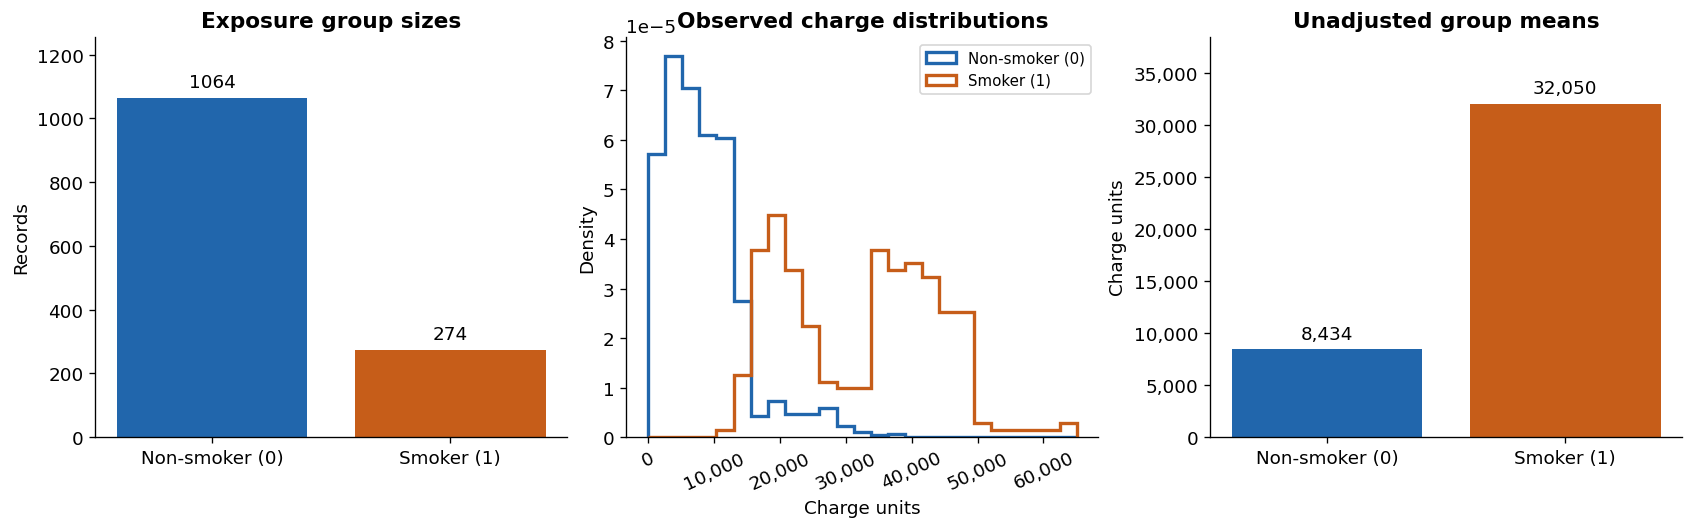

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), layout="constrained")
counts = data.groupby("smoker").size().reindex([0,1])
bars = axes[0].bar(GROUPS, counts, color=[BLUE, ORANGE])
axes[0].bar_label(bars, padding=4); axes[0].set_ylim(0, counts.max()*1.18)
axes[0].set(title="Exposure group sizes", ylabel="Records")
bins = np.linspace(0, data.charges.max()*1.02, 26)
for g, color in enumerate([BLUE, ORANGE]):
    axes[1].hist(data.loc[data.smoker==g,"charges"], bins=bins, density=True,
                 histtype="step", linewidth=2, color=color, label=GROUPS[g])
axes[1].set(title="Observed charge distributions", xlabel="Charge units", ylabel="Density")
charge_axis(axes[1]); axes[1].tick_params(axis="x", rotation=25); axes[1].legend(fontsize=9)
means = data.groupby("smoker").charges.mean().reindex([0,1])
bars = axes[2].bar(GROUPS, means, color=[BLUE, ORANGE])
axes[2].bar_label(bars, labels=[f"{v:,.0f}" for v in means], padding=4)
axes[2].set_ylim(0, means.max()*1.2); axes[2].set(title="Unadjusted group means", ylabel="Charge units")
charge_axis(axes[2], "y")
plt.show()

The smoking groups differ in size and observed charges. Density normalizes each histogram so their shapes can be compared. The mean gap is descriptive and does not establish a causal effect.

# 2. Estimate with five-fold cross-fitting

For each held-out fold, fit a logistic propensity model e(X) on the other folds and separate outcome regressions m₁(X), m₀(X) among smokers and non-smokers. Predict only on held-out records. Use a quadratic age term and categorical region indicators; the alternative adds BMI, BMI², children and age×BMI. Outcome models are separate by exposure, allowing exposure interactions with every feature.

The AIPW score for each record is:

ψ = m₁(X) − m₀(X) + T[Y − m₁(X)]/e(X) − (1 − T)[Y − m₀(X)]/[1 − e(X)].

The estimate is the mean score. Its approximate 95% interval uses the empirical influence-score standard error. It captures sampling uncertainty under regularity and nuisance-model conditions, not bias from confounding, wrong timing, selection or both models being wrong. Cross-fitting does not guarantee correct nuisance models. The small logistic fitting routine below uses Newton iterations with a tiny numerical ridge and checks convergence.

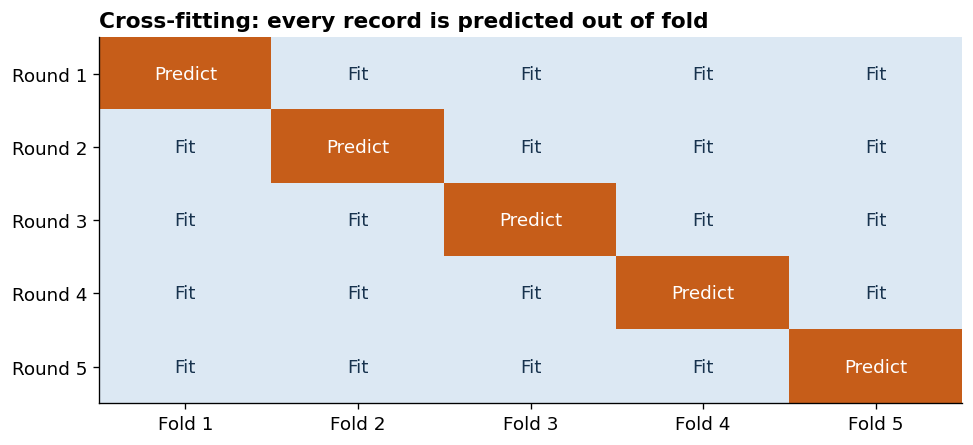

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
from matplotlib.colors import ListedColormap
ax.imshow(np.eye(5), cmap=ListedColormap(["#dce8f3", ORANGE]), vmin=0, vmax=1, aspect="auto")
for row in range(5):
    for col in range(5):
        ax.text(col, row, "Predict" if row==col else "Fit", ha="center", va="center",
                color="white" if row==col else "#17324d")
ax.set_xticks(range(5), [f"Fold {i+1}" for i in range(5)])
ax.set_yticks(range(5), [f"Round {i+1}" for i in range(5)])
ax.set_title("Cross-fitting: every record is predicted out of fold", loc="left")
plt.show()

Each round fits on four folds and predicts the orange held-out fold. This limits in-sample overfitting; it does not address unmeasured confounding.

In [25]:
def features(d, extended=False):
    # Fixed scales avoid fitting preprocessing on held-out data.
    age = (d.age.to_numpy(float) - 40) / 15
    f = {"intercept": np.ones(len(d)), "age": age, "age_squared": age**2,
         "sex_code_1": d.sex.to_numpy(float)}
    for value in (1, 2, 3):
        f[f"region_{value}"] = (d.region.to_numpy() == value).astype(float)
    if extended:
        bmi = (d.bmi.to_numpy(float) - 30) / 6
        f.update(bmi=bmi, bmi_squared=bmi**2,
                 children=d.children.to_numpy(float), age_bmi=age*bmi)
    return pd.DataFrame(f)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -35, 35)))

def fit_logistic(x, t):
    b = np.zeros(x.shape[1])
    penalty = np.eye(x.shape[1]) * 1e-6
    penalty[0, 0] = 0
    for _ in range(100):
        p = sigmoid(x @ b)
        h = x.T @ (np.maximum(p * (1-p), 1e-10)[:, None] * x) + penalty
        step = np.linalg.solve(h, x.T @ (t-p) - penalty @ b)
        b += step
        if np.max(np.abs(step)) < 1e-8:
            return b
    raise RuntimeError("Propensity model failed to converge; inspect covariates and separation")

def estimate(d, extended=False, seed=42, clip=0.01):
    d = d.reset_index(drop=True)
    x = features(d, extended).to_numpy(float)
    t, y = d.smoker.to_numpy(int), d.charges.to_numpy(float)
    assert min(np.bincount(t, minlength=2)) >= 25, "Too few rows per group"
    rng = np.random.default_rng(seed)
    fold = np.zeros(len(d), dtype=int)
    for group in (0, 1):
        indices = rng.permutation(np.flatnonzero(t == group))
        fold[indices] = np.arange(len(indices)) % 5
    e_raw, m0, m1 = (np.zeros(len(d)) for _ in range(3))
    for k in range(5):
        train, test = fold != k, fold == k
        e_raw[test] = sigmoid(x[test] @ fit_logistic(x[train], t[train]))
        for group, dest in [(0, m0), (1, m1)]:
            mask = train & (t == group)
            coef = np.linalg.lstsq(x[mask], y[mask], rcond=None)[0]
            dest[test] = x[test] @ coef
    e = np.clip(e_raw, clip, 1-clip)
    score = m1-m0 + t*(y-m1)/e - (1-t)*(y-m0)/(1-e)
    ate = score.mean()
    se = score.std(ddof=1) / np.sqrt(len(d))
    w1, w0 = t/e, (1-t)/(1-e)
    summary = {"n": len(d), "raw_gap": y[t==1].mean()-y[t==0].mean(),
               "outcome_regression": (m1-m0).mean(),
               "IPW_normalized": np.sum(w1*y)/w1.sum()-np.sum(w0*y)/w0.sum(),
               "AIPW": ate, "approx_95_low": ate-1.96*se,
               "approx_95_high": ate+1.96*se,
               "clipped_fraction": np.mean(e != e_raw)}
    assert np.isfinite(list(summary.values())).all()
    return {"summary": summary, "propensity": e_raw, "weights": w1+w0,
            "scores": score, "data": d, "extended": extended}

primary = estimate(data)
display(pd.Series(primary["summary"], name="Primary specification").to_frame().round(3))

,Primary specification
n,1338.000
raw_gap,23615.964
outcome_regression,23571.405
IPW_normalized,23556.860
AIPW,23634.615
approx_95_low,22235.200
approx_95_high,25034.029
clipped_fraction,0.000


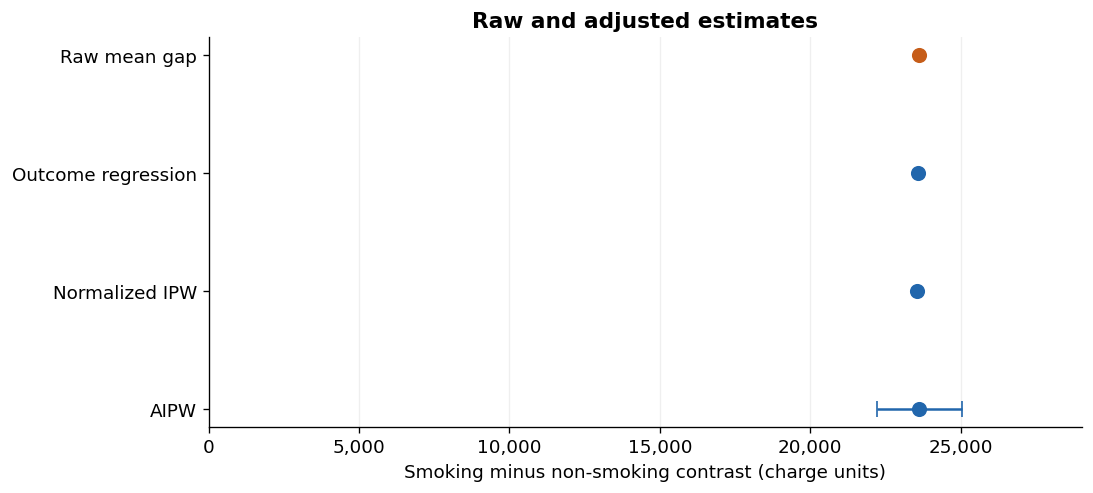

In [26]:
s = primary["summary"]
keys = ["raw_gap", "outcome_regression", "IPW_normalized", "AIPW"]
labels = ["Raw mean gap", "Outcome regression", "Normalized IPW", "AIPW"]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
for i, key in enumerate(keys):
    ax.scatter(s[key], i, color=ORANGE if key=="raw_gap" else BLUE, s=65, zorder=3)
ax.errorbar(s["AIPW"], 3, xerr=[[s["AIPW"]-s["approx_95_low"]],
              [s["approx_95_high"]-s["AIPW"]]], fmt="none", color=BLUE, capsize=5)
ax.set_yticks(range(4), labels); ax.invert_yaxis(); ax.axvline(0, color=GRAY, lw=1)
ax.set(xlabel="Smoking minus non-smoking contrast (charge units)", title="Raw and adjusted estimates")
ax.set_xlim(0, s["approx_95_high"]*1.16); charge_axis(ax); ax.grid(axis="x", alpha=.2)
plt.show()

Only AIPW has an approximate 95% interval here; the other markers are point estimates. Similar estimates do not validate the causal assumptions.

# 3. Overlap, weights and balance

Inspect propensity distributions by group, effective sample sizes, and standardized mean differences (SMDs) before and after weighting. |SMD| below 0.1 is a heuristic, not proof of exchangeability. Very small effective samples, extreme propensities, or persistent imbalance make the estimate unreliable. Clipping probabilities is a numerical safeguard and can introduce bias; it does not repair a lack of overlap.

In [27]:
def diagnostics(result):
    d, e, w = result["data"], result["propensity"], result["weights"]
    t = d.smoker.to_numpy(int)
    display(pd.DataFrame({"smoker": t, "propensity": e}).groupby("smoker").propensity.describe())
    for group in (0, 1):
        wg = w[t==group]
        print(f"Group {group}: n={len(wg)}, effective n={wg.sum()**2/(wg@wg):.1f}, max weight={wg.max():.2f}")
    print("Fraction outside [0.05, 0.95]:", np.mean((e < .05) | (e > .95)))
    rows = []
    for name, values in features(d, result["extended"]).drop(columns="intercept").items():
        a = values.to_numpy()
        sd = np.sqrt((a[t==1].var(ddof=1)+a[t==0].var(ddof=1))/2)
        before = (a[t==1].mean()-a[t==0].mean()) / sd if sd else np.nan
        after = (np.average(a[t==1], weights=w[t==1])-np.average(a[t==0], weights=w[t==0])) / sd if sd else np.nan
        rows.append({"feature": name, "SMD_before": before, "SMD_after": after})
    balance = pd.DataFrame(rows)
    display(balance.round(3))
    if (balance.SMD_after.abs() > .1).any():
        print("Residual measured imbalance: inspect model specification before interpretation.")
    return balance

balance = diagnostics(primary)

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
0,1064.0,0.203721,0.046354,0.103458,0.166021,0.203271,0.233110,0.320147
1,274.0,0.210450,0.049651,0.103458,0.172343,0.207738,0.240773,0.320147


Group 0: n=1064, effective n=1060.2, max weight=1.47
Group 1: n=274, effective n=257.8, max weight=9.67
Fraction outside [0.05, 0.95]: 0.0


,feature,SMD_before,SMD_after
0,age,-0.062,-0.004
1,age_squared,-0.018,0.022
2,sex_code_1,0.190,-0.008
3,region_1,-0.093,0.015
4,region_2,0.166,-0.017
5,region_3,-0.093,0.007


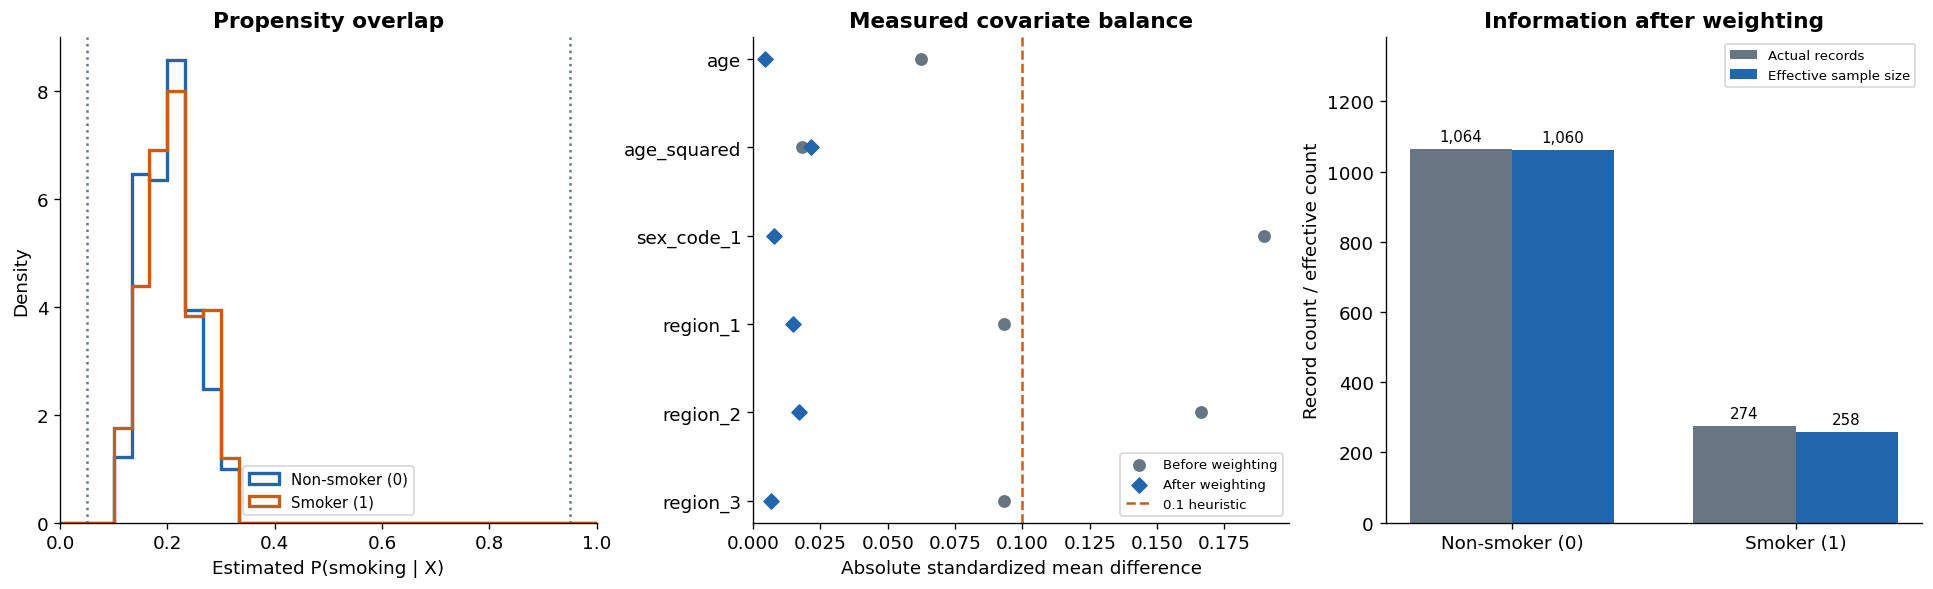

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout="constrained")
t = data.smoker.to_numpy(int)
e, w = primary["propensity"], primary["weights"]
for g, color in enumerate([BLUE, ORANGE]):
    axes[0].hist(e[t==g], bins=np.linspace(0,1,31), density=True,
                 histtype="step", linewidth=2, label=GROUPS[g], color=color)
for threshold in [.05,.95]: axes[0].axvline(threshold, color=GRAY, linestyle=":")
axes[0].set(xlim=(0,1), title="Propensity overlap", xlabel="Estimated P(smoking | X)", ylabel="Density")
axes[0].legend(fontsize=9)
ys = np.arange(len(balance))
axes[1].scatter(balance.SMD_before.abs(), ys, color=GRAY, label="Before weighting", s=45)
axes[1].scatter(balance.SMD_after.abs(), ys, color=BLUE, marker="D", label="After weighting", s=40)
axes[1].axvline(.1, color=ORANGE, linestyle="--", label="0.1 heuristic")
axes[1].set_yticks(ys, balance.feature); axes[1].invert_yaxis()
axes[1].set(title="Measured covariate balance", xlabel="Absolute standardized mean difference", xlim=(0,None))
axes[1].legend(fontsize=8, loc="lower right")
actual = np.array([(t==g).sum() for g in (0,1)])
effective = np.array([w[t==g].sum()**2 / np.sum(w[t==g]**2) for g in (0,1)])
for offset, values, color, label in [(-.18,actual,GRAY,"Actual records"),(.18,effective,BLUE,"Effective sample size")]:
    bars=axes[2].bar(np.arange(2)+offset, values, width=.36, color=color, label=label)
    axes[2].bar_label(bars, labels=[f"{v:,.0f}" for v in values], padding=3, fontsize=9)
axes[2].set_xticks(range(2),GROUPS); axes[2].set_ylim(0,actual.max()*1.3)
axes[2].set(title="Information after weighting", ylabel="Record count / effective count")
axes[2].legend(fontsize=8)
plt.show()

Look for overlapping propensity distributions, smaller weighted SMDs and effective sample sizes close to actual counts. These checks concern measured covariates only; favorable diagnostics cannot rule out unmeasured confounding.

# 4. Sensitivity checks

Compare adjustment sets, cross-fitting seeds, clipping thresholds and duplicate handling. Keep the primary specification chosen in advance; do not choose the largest or most significant estimate. These checks test analysis stability, not unmeasured confounding. Strong substantive conclusions still require richer longitudinal data or a defensible experimental/quasi-experimental design.

In [29]:
checks = {"primary": primary}
checks["add_BMI_children_timing_uncertain"] = estimate(data, extended=True)
checks["seed_7"] = estimate(data, seed=7)
checks["seed_101"] = estimate(data, seed=101)
checks["clip_0.005"] = estimate(data, clip=.005)
checks["clip_0.05"] = estimate(data, clip=.05)
checks["drop_exact_duplicates"] = estimate(data.drop_duplicates())
comparison = pd.DataFrame({name: r["summary"] for name, r in checks.items()}).T
display(comparison.round(2))
print("Alternative specification diagnostics:")
alternative_balance = diagnostics(checks["add_BMI_children_timing_uncertain"])

,n,raw_gap,outcome_regression,IPW_normalized,AIPW,approx_95_low,approx_95_high,clipped_fraction
primary,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
add_BMI_children_timing_uncertain,1338.0,23615.96,23989.96,24098.61,23919.37,22986.06,24852.68,0.0
seed_7,1338.0,23615.96,23576.40,23456.64,23313.53,21949.48,24677.59,0.0
seed_101,1338.0,23615.96,23577.61,23558.42,23544.11,22194.07,24894.16,0.0
clip_0.005,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
clip_0.05,1338.0,23615.96,23571.40,23556.86,23634.61,22235.20,25034.03,0.0
drop_exact_duplicates,1337.0,23609.57,23559.29,23540.54,23617.86,22220.49,25015.22,0.0


Alternative specification diagnostics:


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
0,1064.0,0.204661,0.051356,0.074392,0.164350,0.201062,0.234922,0.594550
1,274.0,0.206995,0.052796,0.081258,0.167237,0.203289,0.240243,0.407649


Group 0: n=1064, effective n=1058.6, max weight=2.47
Group 1: n=274, effective n=255.0, max weight=12.31
Fraction outside [0.05, 0.95]: 0.0


,feature,SMD_before,SMD_after
0,age,-0.062,-0.002
1,age_squared,-0.018,0.022
2,sex_code_1,0.190,-0.006
3,region_1,-0.093,0.012
4,region_2,0.166,-0.008
5,region_3,-0.093,0.010
6,bmi,0.009,0.021
7,bmi_squared,0.061,0.043
8,children,0.019,-0.013
9,age_bmi,-0.067,0.010


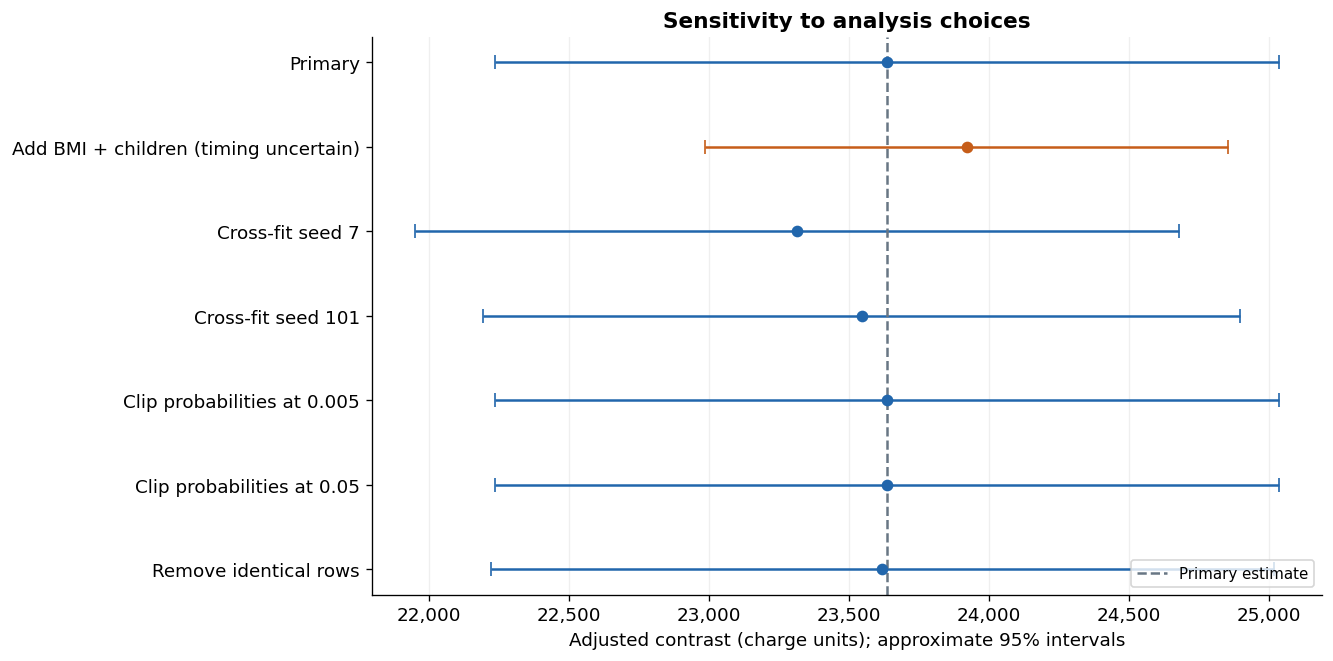

In [30]:
labels = ["Primary", "Add BMI + children (timing uncertain)", "Cross-fit seed 7", "Cross-fit seed 101",
          "Clip probabilities at 0.005", "Clip probabilities at 0.05", "Remove identical rows"]
fig, ax = plt.subplots(figsize=(11, 5.4), layout="constrained")
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.errorbar(row.AIPW, i, xerr=[[row.AIPW-row.approx_95_low], [row.approx_95_high-row.AIPW]],
                fmt="o", color=ORANGE if i==1 else BLUE, capsize=4)
ax.axvline(primary["summary"]["AIPW"], color=GRAY, linestyle="--", label="Primary estimate")
ax.set_yticks(range(len(labels)), labels); ax.invert_yaxis()
ax.set(title="Sensitivity to analysis choices", xlabel="Adjusted contrast (charge units); approximate 95% intervals")
charge_axis(ax); ax.grid(axis="x", alpha=.2); ax.legend(loc="lower right", fontsize=9)
plt.show()

This axis is zoomed to compare specifications. The intervals reuse the same data and are not independent studies. The orange row changes the adjustment assumptions; stability across these checks is not a test for hidden confounding.

# 5. Interpretation and reporting

Use this wording: “The primary AIPW adjusted smoking–charges contrast was [estimate] charge units (approximate 95% interval [low, high]), adjusting for age, sex and region. A causal interpretation would require unverified assumptions about exposure definition, timing, confounding and sampling.”

Do not interpret it as the amount an individual would save by quitting smoking: smoking history and a cessation intervention are not represented here. Do not call the interval protection against confounding. Do not infer population representativeness or that these are 2025 observations.

For a course project, report the question and DAG, assumptions, data quality, raw versus adjusted estimates, diagnostics, sensitivity table and limitations. Prediction accuracy alone does not validate a causal model.

References:

- DoWhy: identifying causal effects

- Statsmodels: treatment effects under conditional independence (background on regression, IPW and AIPW; this notebook implements its own cross-fitted estimator)

- Google Colab

In [31]:
s = primary["summary"]
print(f"Adjusted smoking–charges contrast: {s['AIPW']:,.1f} charge units")
print(f"Approximate 95% interval: [{s['approx_95_low']:,.1f}, {s['approx_95_high']:,.1f}]")
print("Causal interpretation remains conditional on the unverified assumptions above.")
comparison.to_csv("causal_sensitivity_results.csv", index_label="specification")
balance.to_csv("covariate_balance.csv", index=False)
# Optional downloads after reviewing results:
# files.download("causal_sensitivity_results.csv")
# files.download("covariate_balance.csv")

Adjusted smoking–charges contrast: 23,634.6 charge units
Approximate 95% interval: [22,235.2, 25,034.0]
Causal interpretation remains conditional on the unverified assumptions above.


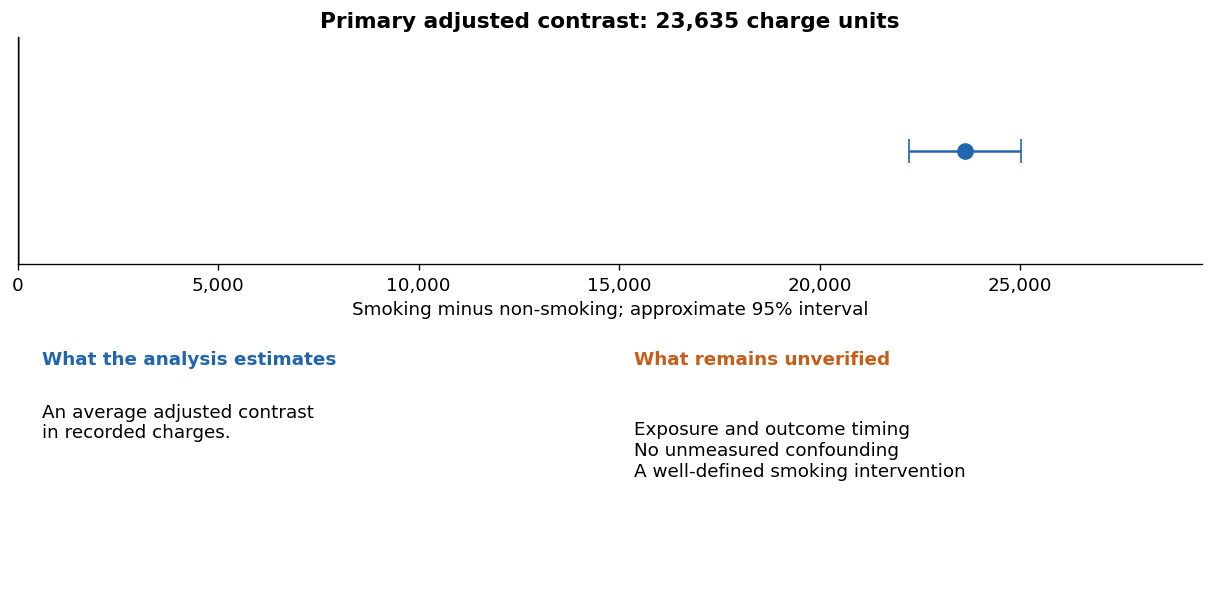

In [32]:
s = primary["summary"]
fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={"height_ratios":[1,1.2]}, layout="constrained")
axes[0].errorbar(s["AIPW"], 0, xerr=[[s["AIPW"]-s["approx_95_low"]],
                    [s["approx_95_high"]-s["AIPW"]]], fmt="o", color=BLUE, capsize=7, markersize=9)
axes[0].axvline(0,color=GRAY); axes[0].set_yticks([])
axes[0].set_xlim(0,s["approx_95_high"]*1.18); charge_axis(axes[0])
axes[0].set(title=f"Primary adjusted contrast: {s['AIPW']:,.0f} charge units",
            xlabel="Smoking minus non-smoking; approximate 95% interval")
axes[1].axis("off")
axes[1].text(.02,.87,"What the analysis estimates",color=BLUE,weight="bold",transform=axes[1].transAxes)
axes[1].text(.02,.6,"An average adjusted contrast\nin recorded charges.",transform=axes[1].transAxes)
axes[1].text(.52,.87,"What remains unverified",color=ORANGE,weight="bold",transform=axes[1].transAxes)
axes[1].text(.52,.46,"Exposure and outcome timing\nNo unmeasured confounding\nA well-defined smoking intervention",transform=axes[1].transAxes)
plt.show()

The interval represents approximate sampling uncertainty. It does not include confounding bias and does not estimate an individual’s savings from quitting smoking.